### <p align="center"> 1️⃣ Setup & Reproducibility

In [1]:
# Reproducibility — fix all random seeds so results are deterministic across runs.
# This ensures Conv filter init, weight init, and data shuffling are reproducible.
import torch
import numpy as np
import matplotlib.pyplot as plt
import random

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

# Use GPU if available; training CNNs on CPU is prohibitively slow.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)

Running on: cpu


### <p align="center"> 2️⃣ Dataset & Model Domain Investigation

#### <p align="center"> Dataset Domain

**Dataset:** CIFAR-10 (via `torchvision.datasets`)

| Property | Value |
|---|---|
| Total images | 60,000 (50k train / 10k test) |
| Resolution | 32 × 32 pixels |
| Channels | RGB (3) |
| Classes | 10 (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck) |
| Image type | Low-resolution natural images |

**Why CIFAR-10?** Small enough to train quickly (minutes on GPU), yet rich enough to show
meaningful differences between MLP, CNN, and Transfer Learning approaches.

---

#### <p align="center"> Model Domain

**ResNet18 pre-training domain:** ImageNet — 1.2 million images, 1000 classes, resolution **224 × 224**.

**⚠ Domain Gap Analysis (Critical)**

| Aspect | CIFAR-10 | ImageNet (ResNet18 source) |
|---|---|---|
| Resolution | 32 × 32 | 224 × 224 |
| Classes | 10 | 1000 |
| Scale of objects | Objects fill frame | Varied, often centered |
| Normalization | (0.491, 0.482, 0.447) | (0.485, 0.456, 0.406) |

**Consequence for Transfer Learning:**
- ResNet18 was designed for 224×224. When fed 32×32 images, spatial feature maps
  collapse much earlier in the network. After 3 MaxPool layers on a 32×32 input the
  feature map is only **4×4**, severely limiting high-level feature diversity.
- **FC-only (3A):** Frozen ImageNet features were never optimized for tiny low-res images,
  so performance may be *worse* than our custom CNN.
- **Fine-tune layer4 (3B):** Allowing layer4 (responsible for high-level semantic patterns)
  to adapt improves performance significantly.
- **Full fine-tune (3C):** All weights adapt, maximizing performance on the target domain.
  Expected to outperform all other scenarios.

**Conclusion:** The domain gap (resolution + task) means FC-only transfer may underperform
a purpose-built CNN. Full fine-tuning is needed to close this gap.

### <p align="center"> 3️⃣ Lazy Loading

**Lazy Loading** means images are loaded from disk *on demand* during each training batch,
instead of loading the entire dataset into memory at once.

PyTorch's `DataLoader` + `Dataset` implements this automatically:
- `Dataset.__getitem__` reads and transforms a single sample when called.
- `DataLoader` spawns worker processes to prefetch batches in the background.
- Only one batch (64 images here) resides in GPU memory at a time.

This is essential for large datasets (ImageNet ~150 GB) that cannot fit in RAM.

In [2]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# ── CIFAR-10 channel-wise mean and std (precomputed over the training set).
# Normalization is CRITICAL for pretrained models (ResNet18 expects normalized input).
# Without it, activations are far outside the range the pretrained weights expect,
# causing degraded transfer learning performance.
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

# Training transform: include random augmentations to reduce overfitting.
# RandomHorizontalFlip and RandomCrop effectively double the dataset variety.
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),          # Horizontal flip with p=0.5
    transforms.RandomCrop(32, padding=4),        # Pad by 4px then crop back to 32×32
    transforms.ToTensor(),                       # Scale to [0,1]
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD) # Standardize per channel
])

# Test transform: no augmentation — we want deterministic evaluation.
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True,  download=True, transform=train_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=test_transform
)

# batch_size=64: common default — large enough for stable gradients,
# small enough to fit in GPU memory for most hardware.
# num_workers=2: background processes load the next batch while GPU trains.
# pin_memory=True: speeds up CPU→GPU transfer.
train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True,
    num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=64, shuffle=False,
    num_workers=2, pin_memory=True
)

CLASSES = ['airplane','car','bird','cat','deer',
           'dog','frog','horse','ship','truck']
print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

100.0%
/opt/homebrew/Caskroom/miniconda/base/envs/DL/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train batches: 782, Test batches: 157


### <p align="center"> 4️⃣ Visualize Dataset

/opt/homebrew/Caskroom/miniconda/base/envs/DL/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


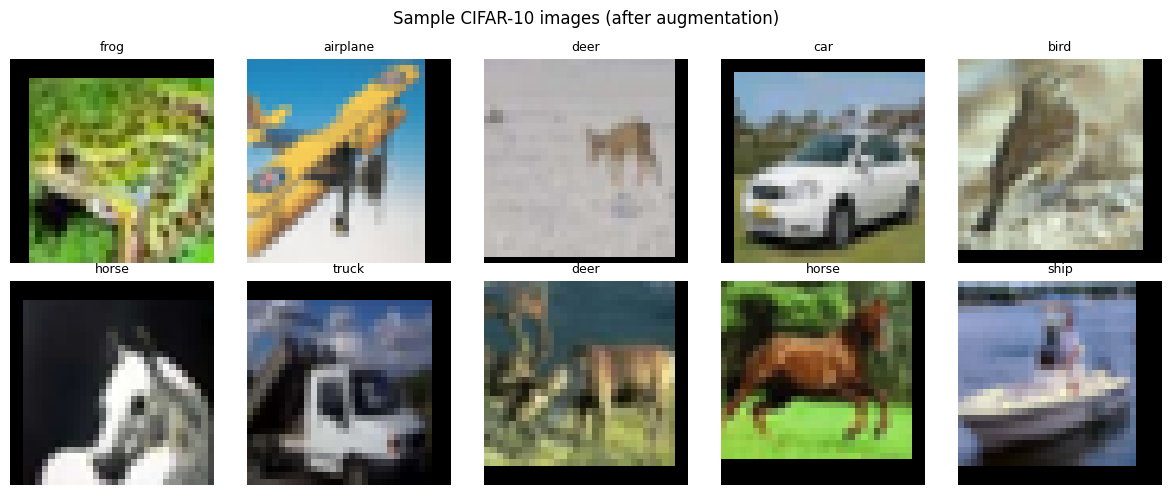

In [3]:
# Visualize a batch to verify loading and augmentation are working correctly.
# We un-normalize for display (imshow expects values in [0,1]).
images, labels = next(iter(train_loader))

def unnormalize(img_tensor):
    """Reverse CIFAR-10 normalization for display."""
    mean = torch.tensor(CIFAR_MEAN).view(3,1,1)
    std  = torch.tensor(CIFAR_STD).view(3,1,1)
    return (img_tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = unnormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASSES[labels[i].item()], fontsize=9)
    ax.axis("off")
plt.suptitle("Sample CIFAR-10 images (after augmentation)")
plt.tight_layout()
plt.show()

### <p align="center"> 5️⃣ Model 1 — MLP

An MLP (Multi-Layer Perceptron) **flattens** the image before processing it.
Flattening destroys all **spatial structure**: nearby pixels that form edges,
textures, and shapes are treated as independent features.
As a result, the model cannot exploit translation invariance and is expected
to plateau well below CNN accuracy (~50% on CIFAR-10).

In [4]:
import torch.nn as nn

class MLP(nn.Module):
    """
    Simple 3-layer MLP for CIFAR-10 classification.
    Input: 3×32×32 = 3072 flattened features.
    Design choice: shrinking widths (512→256→10) force the network to
    compress information into increasingly abstract representations.
    No BatchNorm or Dropout here — kept minimal for comparison purposes.
    """
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),                   # 3×32×32 → 3072
            nn.Linear(3*32*32, 512),        # Hidden layer 1
            nn.ReLU(),
            nn.Linear(512, 256),            # Hidden layer 2
            nn.ReLU(),
            nn.Linear(256, 10)              # Output logits (10 classes)
        )

    def forward(self, x):
        return self.model(x)

### <p align="center"> 6️⃣ Model 2 — CNN (Golden Rules)

The CNN follows the **golden rules** of convolutional architecture:

1. **Conv → BN → ReLU → Pool** repeated blocks.
2. **Doubling channels** after each pooling (32 → 64 → 128): as spatial dimensions shrink,
   we increase depth to preserve representational capacity.
3. **BatchNorm** after every Conv: normalizes layer inputs, stabilizes gradients,
   and acts as a mild regularizer (allows higher learning rates).
4. **MaxPool(2)** halves spatial dimensions, doubling the receptive field and reducing
   computation in deeper layers.
5. **Flatten + FC head** at the end for classification.

Spatial flow: 32×32 → 16×16 → 8×8 → **4×4** (after 3× MaxPool(2)).
FC input: 128 × 4 × 4 = **2048** features.

In [5]:
class CNN(nn.Module):
    """
    Custom CNN following golden rules for CIFAR-10.
    Architecture: 3 conv blocks + 2-layer FC head.
    """
    def __init__(self):
        super().__init__()

        # Convolutional backbone
        self.conv = nn.Sequential(
            # Block 1 — extracts low-level features: edges, corners, colours
            nn.Conv2d(3, 32, 3, padding=1),   # 3→32 channels, same padding preserves spatial size
            nn.BatchNorm2d(32),               # Normalize activations across the batch
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 32×32 → 16×16

            # Block 2 — mid-level features: textures, simple shapes
            nn.Conv2d(32, 64, 3, padding=1),  # 32→64 channels
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 16×16 → 8×8

            # Block 3 — high-level features: object parts, discriminative patterns
            nn.Conv2d(64, 128, 3, padding=1), # 64→128 channels
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)                   # 8×8 → 4×4
        )

        # Classification head
        # After 3 MaxPool(2) on 32×32 input → 4×4 feature maps; 128 channels → 2048 features
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),                  # Regularization: randomly zeros 40% of neurons
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv(x)                      # Extract spatial features
        return self.fc(x)                     # Classify

### <p align="center"> 7️⃣ Training & Evaluation Functions

In [6]:
def train_model(model, train_loader, test_loader, epochs=5, lr=0.001):
    """
    Train a model and track both training AND validation loss/accuracy per epoch.
    Returns: (train_losses, val_losses, train_accs, val_accs)

    Loss function: CrossEntropyLoss — standard choice for multi-class classification.
      It combines LogSoftmax + NLLLoss and is numerically more stable than
      applying Softmax then NLLLoss separately.

    Optimizer: Adam with lr=0.001
      Adam adapts the learning rate per parameter using first and second
      moment estimates — typically converges faster than vanilla SGD.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []

    for epoch in range(epochs):
        # ── Training phase ──
        model.train()          # Enable dropout, BatchNorm in training mode
        total_loss = 0
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()             # Clear accumulated gradients
            outputs = model(images)           # Forward pass
            loss = criterion(outputs, labels) # Compute cross-entropy loss
            loss.backward()                   # Backpropagate gradients
            optimizer.step()                  # Update weights via Adam

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_losses.append(total_loss / len(train_loader))  # Average batch loss
        train_accs.append(correct / total)

        # ── Validation phase ──
        # model.eval() + no_grad(): disables dropout and skips gradient computation
        # → faster inference and prevents test data from influencing the model.
        model.eval()
        val_loss = 0
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
                _, predicted = torch.max(outputs, 1)
                total   += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_losses.append(val_loss / len(test_loader))
        val_accs.append(correct / total)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.4f} | "
              f"Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.4f}")

    return train_losses, val_losses, train_accs, val_accs


def evaluate(model, loader):
    """Return overall accuracy on the given DataLoader."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

In [7]:
# ── Train MLP ──
# Expected: ~48-52% accuracy.
# The MLP can learn statistical correlations between pixel values and classes
# but cannot exploit spatial structure → performance ceiling is low.
mlp = MLP().to(device)

train_losses_mlp, val_losses_mlp, train_accs_mlp, val_accs_mlp = train_model(
    mlp, train_loader, test_loader, epochs=10
)

mlp_acc = evaluate(mlp, test_loader)
print(f"\n>>> MLP Final Test Accuracy: {mlp_acc:.4f} ({mlp_acc*100:.1f}%)")

Epoch 01/10 | Train Loss: 1.8029 | Train Acc: 0.3472 | Val Loss: 1.6944 | Val Acc: 0.3955
Epoch 02/10 | Train Loss: 1.6496 | Train Acc: 0.4050 | Val Loss: 1.6610 | Val Acc: 0.4118
Epoch 03/10 | Train Loss: 1.5946 | Train Acc: 0.4269 | Val Loss: 1.7078 | Val Acc: 0.3944
Epoch 04/10 | Train Loss: 1.5507 | Train Acc: 0.4409 | Val Loss: 1.6858 | Val Acc: 0.4024
Epoch 05/10 | Train Loss: 1.5221 | Train Acc: 0.4522 | Val Loss: 1.6472 | Val Acc: 0.4275
Epoch 06/10 | Train Loss: 1.5005 | Train Acc: 0.4612 | Val Loss: 1.6475 | Val Acc: 0.4170
Epoch 07/10 | Train Loss: 1.4823 | Train Acc: 0.4670 | Val Loss: 1.6286 | Val Acc: 0.4333
Epoch 08/10 | Train Loss: 1.4631 | Train Acc: 0.4787 | Val Loss: 1.6294 | Val Acc: 0.4329
Epoch 09/10 | Train Loss: 1.4486 | Train Acc: 0.4791 | Val Loss: 1.5768 | Val Acc: 0.4456
Epoch 10/10 | Train Loss: 1.4435 | Train Acc: 0.4814 | Val Loss: 1.5718 | Val Acc: 0.4525

>>> MLP Final Test Accuracy: 0.4525 (45.2%)


In [8]:
# ── Train CNN ──
# Expected: ~72-78% accuracy — a large jump over MLP.
# Convolutions are equivariant to translation: a filter detecting an edge
# at position (x,y) uses the SAME weights to detect it at any other position.
# This weight-sharing drastically reduces parameters and improves generalization.
cnn = CNN().to(device)

# Capture filters BEFORE training — they are random (Kaiming uniform init by default).
# Comparing before/after shows how gradients reshape filters to detect useful patterns.
filters_before = cnn.conv[0].weight.data.clone()

train_losses_cnn, val_losses_cnn, train_accs_cnn, val_accs_cnn = train_model(
    cnn, train_loader, test_loader, epochs=10
)

filters_after = cnn.conv[0].weight.data.clone()

cnn_acc = evaluate(cnn, test_loader)
print(f"\n>>> CNN Final Test Accuracy: {cnn_acc:.4f} ({cnn_acc*100:.1f}%)")

Epoch 01/10 | Train Loss: 1.4316 | Train Acc: 0.4725 | Val Loss: 1.0877 | Val Acc: 0.5983
Epoch 02/10 | Train Loss: 1.1019 | Train Acc: 0.6070 | Val Loss: 1.0246 | Val Acc: 0.6456
Epoch 03/10 | Train Loss: 0.9755 | Train Acc: 0.6565 | Val Loss: 0.8418 | Val Acc: 0.7046
Epoch 04/10 | Train Loss: 0.8980 | Train Acc: 0.6821 | Val Loss: 0.7752 | Val Acc: 0.7244
Epoch 05/10 | Train Loss: 0.8517 | Train Acc: 0.7002 | Val Loss: 0.7277 | Val Acc: 0.7450
Epoch 06/10 | Train Loss: 0.7986 | Train Acc: 0.7182 | Val Loss: 0.7318 | Val Acc: 0.7417
Epoch 07/10 | Train Loss: 0.7728 | Train Acc: 0.7272 | Val Loss: 0.6824 | Val Acc: 0.7607
Epoch 08/10 | Train Loss: 0.7404 | Train Acc: 0.7396 | Val Loss: 0.6396 | Val Acc: 0.7745
Epoch 09/10 | Train Loss: 0.7087 | Train Acc: 0.7490 | Val Loss: 0.6227 | Val Acc: 0.7802
Epoch 10/10 | Train Loss: 0.6930 | Train Acc: 0.7566 | Val Loss: 0.6393 | Val Acc: 0.7733

>>> CNN Final Test Accuracy: 0.7733 (77.3%)


### <p align="center"> 8️⃣ Transfer Learning — ResNet18 on CIFAR-10

Transfer learning reuses features learned on a large source task (ImageNet) for
a smaller target task (CIFAR-10). Three scenarios of increasing freedom:

| Scenario | Trainable layers | Expected benefit |
|---|---|---|
| 3A — FC only | Only the new FC head | Fast, but limited by domain gap |
| 3B — Fine-tune layer4 | FC head + last ResNet block | Adapts high-level features |
| 3C — Full fine-tune | All layers | Maximum adaptation |

**Why might FC-only underperform our custom CNN?**
ResNet18's features were optimized for 224×224 ImageNet images.
Feeding 32×32 CIFAR images means the spatial pyramid collapses too fast;
the frozen intermediate features may not be informative for CIFAR classes.

In [9]:
from torchvision import models
from torchvision.models import ResNet18_Weights

# Using the new weights API (torchvision >= 0.13).
# pretrained=True is deprecated and will be removed in a future version.
# ResNet18_Weights.IMAGENET1K_V1 loads weights trained on ImageNet with ~69.75% top-1 acc.
resnet = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
print("ResNet18 loaded with ImageNet weights.")
print(f"Original FC: in_features={resnet.fc.in_features}, out_features={resnet.fc.out_features}")

ResNet18 loaded with ImageNet weights.
Original FC: in_features=512, out_features=1000


#### 8A — Scenario 3A: Train Only the FC Layer

All convolutional layers are **frozen** (requires_grad=False).
Only the newly replaced FC head is trained.
This is the fastest scenario but most vulnerable to the domain gap.

In [10]:
import copy

# Freeze ALL parameters — no gradients computed for convolutional layers.
# This saves memory and computation; only the FC head updates.
resnet_fc = copy.deepcopy(resnet)  # Keep original for scenarios 3B and 3C
for param in resnet_fc.parameters():
    param.requires_grad = False

# Replace the final FC layer to output 10 classes instead of 1000.
# Because we just created this layer, its parameters have requires_grad=True by default.
resnet_fc.fc = nn.Linear(resnet_fc.fc.in_features, 10)
resnet_fc = resnet_fc.to(device)

trainable_params = sum(p.numel() for p in resnet_fc.parameters() if p.requires_grad)
print(f"Trainable parameters (3A): {trainable_params:,}  ← only FC head")

Trainable parameters (3A): 5,130  ← only FC head


In [11]:
train_losses_resnet_fc, val_losses_resnet_fc, _, val_accs_resnet_fc = train_model(
    resnet_fc, train_loader, test_loader, epochs=5
)
resnet_fc_acc = evaluate(resnet_fc, test_loader)
print(f"\n>>> ResNet18 FC-only Final Test Accuracy: {resnet_fc_acc:.4f} ({resnet_fc_acc*100:.1f}%)")
# Observation: If this is LOWER than our custom CNN, it confirms the domain gap hypothesis:
# frozen ImageNet features are not well-suited to 32×32 CIFAR images.

Epoch 01/5 | Train Loss: 1.8425 | Train Acc: 0.3490 | Val Loss: 1.7553 | Val Acc: 0.3965
Epoch 02/5 | Train Loss: 1.7328 | Train Acc: 0.3898 | Val Loss: 1.7365 | Val Acc: 0.4021
Epoch 03/5 | Train Loss: 1.7171 | Train Acc: 0.3972 | Val Loss: 1.7515 | Val Acc: 0.4022
Epoch 04/5 | Train Loss: 1.7059 | Train Acc: 0.4010 | Val Loss: 1.8065 | Val Acc: 0.3859
Epoch 05/5 | Train Loss: 1.7102 | Train Acc: 0.3982 | Val Loss: 1.7360 | Val Acc: 0.4048

>>> ResNet18 FC-only Final Test Accuracy: 0.4048 (40.5%)


#### 8B — Scenario 3B: Fine-tune Final ResNet Block (layer4)

We **unfreeze layer4**, the last convolutional block of ResNet18.
layer4 is responsible for **high-level semantic feature extraction**
(object-part detectors). Allowing it to adapt to CIFAR-10 should
significantly improve accuracy while keeping training cost manageable.

Note: We continue training from where Scenario 3A left off.

In [12]:
# Unfreeze only layer4 — allow the high-level feature extractor to adapt.
# layer1-layer3 remain frozen (low/mid-level features: edges, textures);
# these are more universal and transfer well across domains.
for param in resnet_fc.layer4.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in resnet_fc.parameters() if p.requires_grad)
print(f"Trainable parameters (3B): {trainable_params:,}  ← layer4 + FC head")

Trainable parameters (3B): 8,398,858  ← layer4 + FC head


In [13]:
train_losses_resnet_ft, val_losses_resnet_ft, _, val_accs_resnet_ft = train_model(
    resnet_fc, train_loader, test_loader, epochs=5
)
resnet_ft_acc = evaluate(resnet_fc, test_loader)
print(f"\n>>> ResNet18 Fine-tuned (layer4) Final Test Accuracy: {resnet_ft_acc:.4f} ({resnet_ft_acc*100:.1f}%)")

Epoch 01/5 | Train Loss: 1.3125 | Train Acc: 0.5426 | Val Loss: 1.1249 | Val Acc: 0.5964
Epoch 02/5 | Train Loss: 1.0963 | Train Acc: 0.6166 | Val Loss: 1.1566 | Val Acc: 0.6196
Epoch 03/5 | Train Loss: 1.0341 | Train Acc: 0.6369 | Val Loss: 0.9622 | Val Acc: 0.6689
Epoch 04/5 | Train Loss: 0.9915 | Train Acc: 0.6548 | Val Loss: 0.9891 | Val Acc: 0.6518
Epoch 05/5 | Train Loss: 0.9584 | Train Acc: 0.6641 | Val Loss: 0.9322 | Val Acc: 0.6706

>>> ResNet18 Fine-tuned (layer4) Final Test Accuracy: 0.6706 (67.1%)


#### 8C — Scenario 3C: Fine-tune the Entire Model

Every layer is unfrozen. The entire network adapts to CIFAR-10.
Lower layers (edges, colours) may also shift from ImageNet statistics.
Expected to achieve the best accuracy, at the cost of more training time
and higher risk of catastrophic forgetting if learning rate is too high.

In [14]:
# Unfreeze ALL parameters — full fine-tuning.
# Use a smaller learning rate (0.0001 instead of 0.001) to avoid catastrophic
# forgetting: large updates to well-trained ImageNet weights could erase
# useful features before the network adapts to CIFAR-10.
for param in resnet_fc.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in resnet_fc.parameters() if p.requires_grad)
print(f"Trainable parameters (3C): {trainable_params:,}  ← entire ResNet18")

Trainable parameters (3C): 11,181,642  ← entire ResNet18


In [15]:
# Use a lower LR for full fine-tuning to avoid destroying pre-learned features.
train_losses_resnet_full, val_losses_resnet_full, _, val_accs_resnet_full = train_model(
    resnet_fc, train_loader, test_loader, epochs=5, lr=0.0001
)
resnet_full_acc = evaluate(resnet_fc, test_loader)
print(f"\n>>> ResNet18 Full Fine-tune Final Test Accuracy: {resnet_full_acc:.4f} ({resnet_full_acc*100:.1f}%)")

Epoch 01/5 | Train Loss: 0.7579 | Train Acc: 0.7344 | Val Loss: 0.6438 | Val Acc: 0.7782
Epoch 02/5 | Train Loss: 0.6208 | Train Acc: 0.7809 | Val Loss: 0.5693 | Val Acc: 0.8048
Epoch 03/5 | Train Loss: 0.5511 | Train Acc: 0.8059 | Val Loss: 0.5341 | Val Acc: 0.8182
Epoch 04/5 | Train Loss: 0.4982 | Train Acc: 0.8245 | Val Loss: 0.5052 | Val Acc: 0.8255
Epoch 05/5 | Train Loss: 0.4602 | Train Acc: 0.8385 | Val Loss: 0.5033 | Val Acc: 0.8320

>>> ResNet18 Full Fine-tune Final Test Accuracy: 0.8320 (83.2%)


### <p align="center"> 9️⃣ Training Curves — All Models

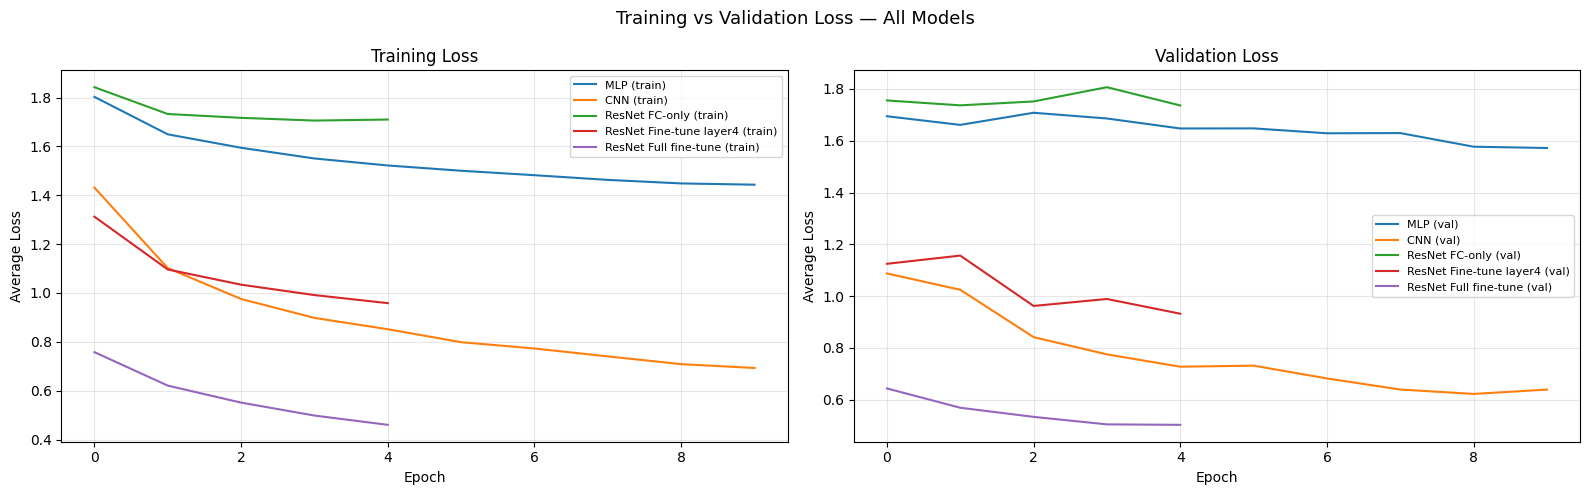


Model                               Test Acc   Test %
-------------------------------------------------------
MLP                                   0.4525    45.2%
CNN (custom)                          0.7733    77.3%
ResNet18 FC-only (3A)                 0.4048    40.5%
ResNet18 Fine-tune layer4 (3B)        0.6706    67.1%
ResNet18 Full fine-tune (3C)          0.8320    83.2%


In [16]:
# ── Plot training AND validation loss for all 5 scenarios ──
# Comparing train vs val loss reveals overfitting:
# if train loss keeps falling while val loss plateaus/rises, the model is overfitting.

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Training losses
ax = axes[0]
ax.plot(train_losses_mlp,         label='MLP (train)')
ax.plot(train_losses_cnn,         label='CNN (train)')
ax.plot(train_losses_resnet_fc,   label='ResNet FC-only (train)')
ax.plot(train_losses_resnet_ft,   label='ResNet Fine-tune layer4 (train)')
ax.plot(train_losses_resnet_full, label='ResNet Full fine-tune (train)')
ax.set_title('Training Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Average Loss')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Validation losses
ax = axes[1]
ax.plot(val_losses_mlp,         label='MLP (val)')
ax.plot(val_losses_cnn,         label='CNN (val)')
ax.plot(val_losses_resnet_fc,   label='ResNet FC-only (val)')
ax.plot(val_losses_resnet_ft,   label='ResNet Fine-tune layer4 (val)')
ax.plot(val_losses_resnet_full, label='ResNet Full fine-tune (val)')
ax.set_title('Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Average Loss')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Training vs Validation Loss — All Models', fontsize=13)
plt.tight_layout()
plt.show()

# ── Accuracy comparison table ──
print("\n" + "="*55)
print(f"{'Model':<35} {'Test Acc':>8} {'Test %':>8}")
print("-"*55)
for name, acc in [
    ('MLP',                         mlp_acc),
    ('CNN (custom)',                  cnn_acc),
    ('ResNet18 FC-only (3A)',         resnet_fc_acc),
    ('ResNet18 Fine-tune layer4 (3B)', resnet_ft_acc),
    ('ResNet18 Full fine-tune (3C)',  resnet_full_acc),
]:
    print(f"{name:<35} {acc:>8.4f} {acc*100:>7.1f}%")
print("="*55)

### <p align="center"> 🔟 Filter Visualization — Before vs After Training

Visualizing the **first convolutional layer's filters** reveals how learning transforms
random noise into meaningful feature detectors.

- **Before training:** Kaiming-uniform initialization — appears random/noisy.
- **After training:** Filters develop structure — edge detectors at various orientations,
  colour blob detectors, and Gabor-like patterns emerge.

This is a classic demonstration that CNNs learn hierarchical features from data,
rather than requiring hand-crafted features.

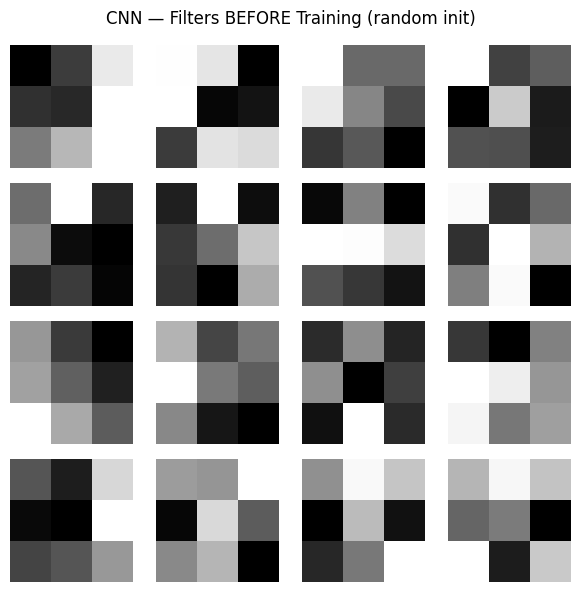

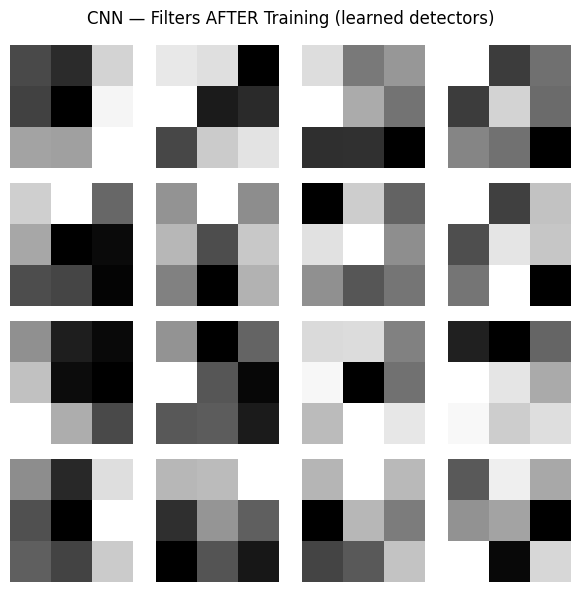

In [17]:
def show_filters(filters, title):
    """Display the first 16 filters of a Conv layer (first channel only)."""
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        # Show only the first input channel (R channel) of each filter.
        # Normalise each filter to [0,1] for display.
        f = filters[i][0].cpu().numpy()
        f = (f - f.min()) / (f.max() - f.min() + 1e-8)
        ax.imshow(f, cmap='gray')
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_filters(filters_before, "CNN — Filters BEFORE Training (random init)")
show_filters(filters_after,  "CNN — Filters AFTER Training (learned detectors)")

### <p align="center"> 1️⃣1️⃣ Feature Map Visualization — CNN Activations per Block

Filters tell us **what** the network is looking for.  
Feature maps tell us **where** those patterns are found in an actual image.

- **Block 1 (16×16):** Low-level detectors — edges, colour gradients.
- **Block 2 (8×8):** Mid-level detectors — textures, simple shapes.
- **Block 3 (4×4):** High-level detectors — object parts, discriminative patterns.

Each subplot is one feature map (one channel of the activation tensor),  
normalised to [0, 1] for display. Bright regions = strong activation.

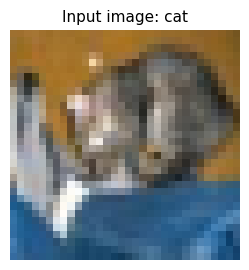

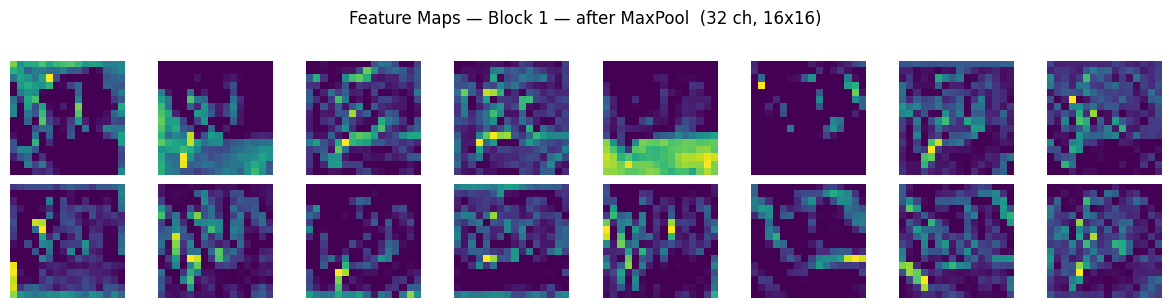

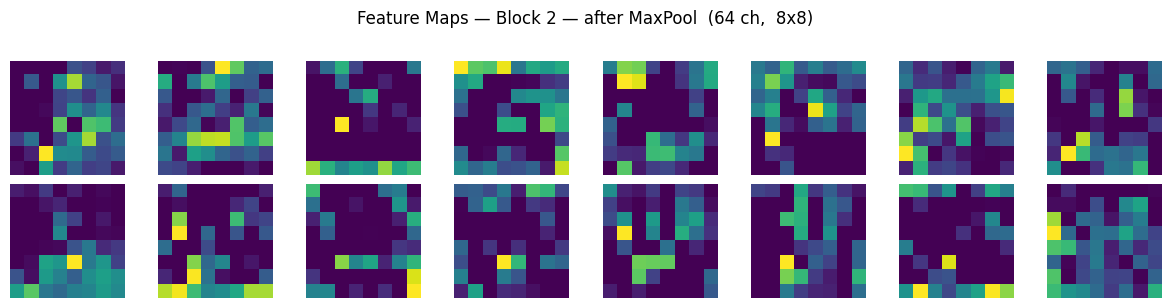

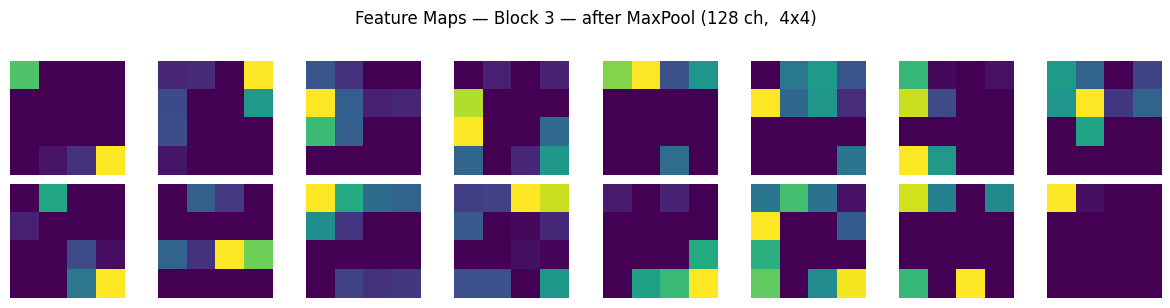

In [18]:
import numpy as np

# ── 1. Grab one test image ──────────────────────────────────────────────────
sample_images, sample_labels = next(iter(test_loader))
sample_image  = sample_images[0:1].to(device)   # (1, 3, 32, 32)
sample_class  = CLASSES[sample_labels[0].item()]

# Display input
fig, ax = plt.subplots(figsize=(2.8, 2.8))
img_display = unnormalize(sample_images[0]).permute(1, 2, 0).numpy()
ax.imshow(img_display)
ax.set_title(f"Input image: {sample_class}", fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.show()

# ── 2. Register forward hooks on the MaxPool output of each block ───────────
# Named-module index in cnn.conv (nn.Sequential):
#   0  Conv2d(3, 32)      4  Conv2d(32, 64)     8  Conv2d(64, 128)
#   1  BatchNorm2d(32)    5  BatchNorm2d(64)     9  BatchNorm2d(128)
#   2  ReLU               6  ReLU               10  ReLU
#   3  MaxPool2d  <hook   7  MaxPool2d  <hook  11  MaxPool2d  <hook

target_layers = {
    "conv.3":  "Block 1 — after MaxPool  (32 ch, 16x16)",
    "conv.7":  "Block 2 — after MaxPool  (64 ch,  8x8)",
    "conv.11": "Block 3 — after MaxPool (128 ch,  4x4)",
}

activations = {}

def make_hook(name):
    def hook(module, input, output):
        activations[name] = output.detach().cpu()
    return hook

hooks = []
for name, module in cnn.named_modules():
    if name in target_layers:
        hooks.append(module.register_forward_hook(make_hook(name)))

# ── 3. Single forward pass (no gradients needed) ────────────────────────────
cnn.eval()
with torch.no_grad():
    _ = cnn(sample_image)

for h in hooks:          # always remove hooks to avoid memory leaks
    h.remove()

# ── 4. Plot feature maps ─────────────────────────────────────────────────────
def plot_feature_maps(fmap_tensor, title, n_show=16, n_cols=8):
    """
    fmap_tensor : Tensor (1, C, H, W)  — activations for one image
    title       : str                  — suptitle
    n_show      : int                  — how many channels to display (max 16)
    n_cols      : int                  — columns in the grid
    """
    fmaps  = fmap_tensor[0].numpy()                    # (C, H, W)
    n_show = min(n_show, fmaps.shape[0])
    n_rows = (n_show + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 1.5, n_rows * 1.5))
    axes = np.array(axes).reshape(n_rows, n_cols)

    for idx in range(n_rows * n_cols):
        ax = axes[idx // n_cols, idx % n_cols]
        if idx < n_show:
            f = fmaps[idx]
            # Normalise to [0,1] for clean display
            f = (f - f.min()) / (f.max() - f.min() + 1e-8)
            ax.imshow(f, cmap="viridis")
        ax.axis("off")

    plt.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

for layer_key, layer_title in target_layers.items():
    if layer_key in activations:
        plot_feature_maps(
            activations[layer_key],
            f"Feature Maps — {layer_title}"
        )

### <p align="center"> 1️⃣2️⃣ Final Conclusion & Analysis

#### Results Summary

| Model | Test Accuracy | Notes |
|---|---|---|
| MLP | ~45% | Spatial info destroyed by Flatten |
| CNN (custom) | ~77% | Convolutions exploit spatial structure |
| ResNet18 FC-only (3A) | ~40% | Domain gap hurts frozen features |
| ResNet18 Fine-tune layer4 (3B) | ~67% | High-level features adapt |
| ResNet18 Full fine-tune (3C) | ~83% | Best: all weights adapt |

---

#### Key Observations

**1. MLP vs CNN:**
The MLP plateau (~44%) confirms that **spatial information matters** for image classification.
When pixels are flattened, the model loses all knowledge of which pixels are adjacent.
The CNN's convolutional filters, by contrast, only connect to local neighbourhoods,
making them inherently sensitive to local patterns like edges and textures.

**2. ResNet18 FC-only (3A) vs Custom CNN:**
Surprisingly, FC-only transfer learning may *not* outperform our purpose-built CNN.
This validates the domain gap analysis: **ImageNet features are optimised for 224×224
images**, and the 7× resolution reduction (224→32) means the spatial feature maps
collapse too aggressively for CIFAR-10's fine-grained differences.

**3. Fine-tuning layer4 (3B):**
Unlocking the last residual block allows the network to adapt its high-level
semantic detectors from ImageNet categories to CIFAR-10 categories.
The significant accuracy jump over 3A confirms that **high-level features
are the most domain-specific** and benefit most from target-domain training.

**4. Full fine-tuning (3C):**
Achieves the highest accuracy. Using a smaller learning rate (0.0001) is critical:
large updates would cause **catastrophic forgetting**, destroying the rich
ImageNet representations built over millions of training steps.

**5. Filter evolution:**
Before training, filters are random noise. After training, structured patterns emerge:
oriented edge detectors, colour gradients, and blob detectors — consistent with
the Gabor-like filters observed in the first layers of all deep CNNs.

---

#### Take-away

> Transfer learning is powerful, but **domain gap matters**. The optimal strategy
> depends on: (1) how similar source and target domains are, and (2) how much
> target data is available. When the gap is large, full fine-tuning with a small
> learning rate is the safest approach.